### Análisis Exploratorio de Datos (EDA)

Equipo:17
Anuar Olmos López A01092551
Arturo Arellano Coyotl A01796088
Mireya Isabel Perez del Razo A01795608

Profesores
Dra. Grettel Barceló Alonso
Dr. Luis Eduardo Falcón Morales

Fecha: 31/01/2026

## Indice
1. Carga y Vista Inicial de Datos
2. Análisis de Valores Faltantes
3. Estadísticas Descriptivas
4. Análisis de Valores Atípicos
5. Cardinalidad de Variables Categóricas
6. Análisis de Distribuciones
7. Análisis de Correlaciones
8. Análisis Bivariado
9. Análisis de Desequilibrio de Clases
10. Combinaciones de Salida
11. Ambigüedad del Lenguaje
12. Conclusiones del EDA

1. Carga y Vista Inicial de Datos

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar la base de datos
df = pd.read_csv("../data/raw/Base de Datos sucia v3.csv")
print(f"Tamaño del dataset: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head()

Tamaño del dataset: 3000 filas, 5 columnas


,estado_accion,estado_velocidad,frase,accion,velocidad
0,apagado,detenida,por favor prender,prender,detenida
1,apagado,detenida,prendete rapido,prender,detenida
2,apagado,detenida,enciende,prender,detenida
3,apagado,detenida,activate!,prender,detenida
4,prendida,detenida,Hey Apaguete,apagar,detenida


In [82]:
print("Tipo de variables\n" )

df.info()

Tipo de variables

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   estado_accion     3000 non-null   object
 1   estado_velocidad  3000 non-null   object
 2   frase             3000 non-null   object
 3   accion            2708 non-null   object
 4   velocidad         2406 non-null   object
dtypes: object(5)
memory usage: 117.3+ KB


2. Análisis de Valores Faltantes

In [83]:
print("Valores faltantes:\n")
print(df.isnull().sum())

Valores faltantes:

estado_accion         0
estado_velocidad      0
frase                 0
accion              292
velocidad           594
dtype: int64


1 ¿Hay valores faltantes en el conjunto de datos? ¿Se pueden identificar patrones de ausencia?
Si existen valores faltantes en las variables de salida de acción y velocidad.
Se pueden identificar patrones de ausencia ya que en ocasiones los usuarios solo indican la acción sin establecer la velocidad y viceversa los usuarios pueden modificar la velocidad a la que quieren que se mueva la silla sin establecer una acción

3. Estadísticas Descriptivas

In [84]:
df['num_palabras'] = df['frase'].str.split().str.len()
df['num_caracteres'] = df['frase'].str.len()
print("Estadísticas de las frases")
df[['num_palabras', 'num_caracteres']].describe()

Estadísticas de las frases


,num_palabras,num_caracteres
count,3000.000000,3000.000000
mean,4.304000,24.584333
std,1.607621,8.991913
min,1.000000,5.000000
25%,3.000000,18.000000
50%,4.000000,24.000000
75%,5.000000,30.000000
max,10.000000,57.000000


In [87]:
print(f"valores duplicados: {df.duplicated().sum()} \n")


valores duplicados: 96 



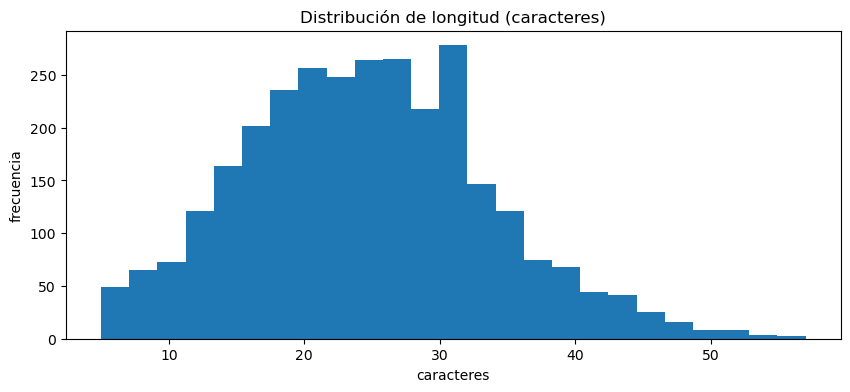

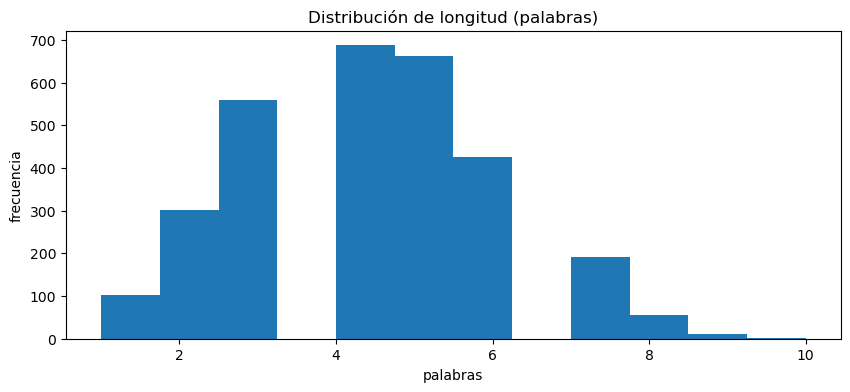

In [100]:
plt.figure(figsize=(10,4))
plt.hist(df["num_caracteres"], bins=25)
plt.title("Distribución de longitud (caracteres)")
plt.xlabel("caracteres")
plt.ylabel("frecuencia")
plt.show()

plt.figure(figsize=(10,4))
plt.hist(df["num_palabras"], bins=12)
plt.title("Distribución de longitud (palabras)")
plt.xlabel("palabras")
plt.ylabel("frecuencia")
plt.show()

2¿Cuáles son las estadísticas resumidas del conjunto de datos?

La mayoría de las oraciones tiene entre 3 y 5 palabras
Las oracionaes tienen en su mayoría menos de 30 caracteres, se aprecia un ligero sesgo a la derecha

4. Análisis de Valores Atípicos

In [ ]:
from collections import Counter

todas_palabras = " ".join(df['frase']).lower().split()
print(Counter(todas_palabras))

print(f"Palabras distintas usadas en el dataset: {len(Counter(todas_palabras))}")

Counter({'la': 782, 'a': 619, 'por': 560, 'velocidad': 526, 'favor': 516, 'de': 508, 'oye': 372, 'silla': 369, 'hey': 352, 'derecha': 339, 'izquierda': 331, 'ahorita': 326, 'normal': 325, 'en': 318, 'ya': 305, 'ahora': 288, 'inmediato': 278, 'atras': 258, 'para': 247, 'adelante': 243, 'mas': 239, 'gira': 218, 'hacia': 202, 'con': 174, 'rapido': 134, 'enfrente': 130, 've': 130, 'reversa': 118, 'dobla': 114, 'una': 104, 'voltea': 99, 'friega': 98, 'mueve': 92, 'este': 92, 'mete': 86, 'muevete': 86, 'momento': 78, 'echale': 70, 'despacio': 66, 'avanza': 66, 'corto': 66, 'lento': 64, 'dale': 58, 'pa': 57, 'frente': 57, 'manten': 55, 'apaga': 52, 'continua': 51, 'vamos': 50, 'modo': 49, 'reduce': 49, 'da': 48, 'calma': 48, 'al': 46, 'sigue': 43, "pa'": 42, 'aumenta': 41, 'subele': 41, 'acelera': 40, 'un': 40, 'derecho': 36, 'poco': 36, 'rueda': 36, 'apurate': 35, 'cuidado': 35, 'no': 35, 'tan': 35, 'tranqui': 33, 'desacelera': 29, 'suavecito': 29, 'retrocede': 29, 'enciendete': 28, 'baja': 

,num_caracteres,num_palabras
accion,,
izquierda,29.14,5.20
derecha,27.42,5.14
adelante,24.96,4.24
atras,23.93,4.14
adelante + izquierda,23.81,4.34
adelante + derecha,22.00,4.43
apagar,20.63,3.47
prender,20.45,3.43


<Figure size 1000x400 with 0 Axes>

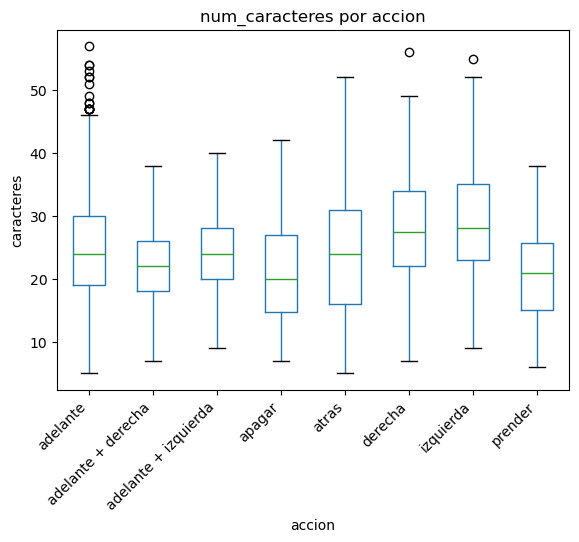

<Figure size 800x400 with 0 Axes>

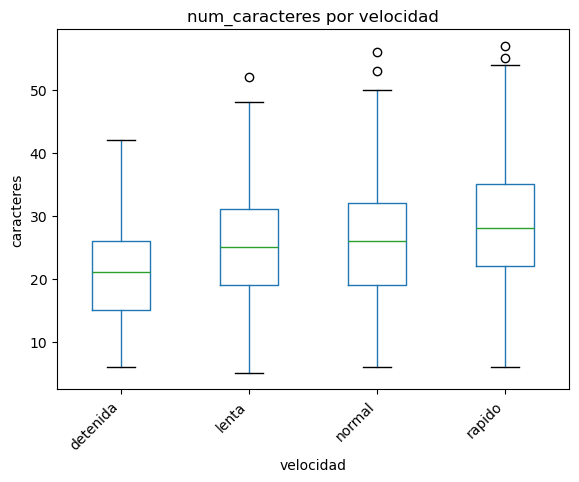

In [94]:

if "accion" in df.columns:
    display(df.groupby("accion")[["num_caracteres", "num_palabras"]].mean().round(2).sort_values("num_caracteres", ascending=False))
    plt.figure(figsize=(10,4))
    df.boxplot(column="num_caracteres", by="accion", grid=False)
    plt.title("num_caracteres por accion")
    plt.suptitle("")
    plt.xlabel("accion")
    plt.ylabel("caracteres")
    plt.xticks(rotation=45, ha="right")
    plt.show()
if "velocidad" in df.columns:
    plt.figure(figsize=(8,4))
    df.boxplot(column="num_caracteres", by="velocidad", grid=False)
    plt.title("num_caracteres por velocidad")
    plt.suptitle("")
    plt.xlabel("velocidad")
    plt.ylabel("caracteres")
    plt.xticks(rotation=45, ha="right")
    plt.show()

In [101]:
col_texto = "frase" if "frase" in df.columns else df.columns[0]

print("\nTop 10 frases más largas:")
display(df[[col_texto, "num_caracteres", "num_palabras"]].sort_values("num_caracteres", ascending=False).head(10))

print("\nTop 10 frases más cortas:")
display(df[[col_texto, "num_caracteres", "num_palabras"]].sort_values("num_caracteres", ascending=True).head(10))


Top 10 frases más largas:


,frase,num_caracteres,num_palabras
806,silla muevete para enfrente mete velocidad de ...,57,8
1269,silla gira para la derecha a velocidad normal ...,56,10
2427,hey ve al lado izquierdo con mas velocidad de ...,55,10
1019,Por Favor Dale Para Enfrente Con Mas Velocidad...,54,9
2518,POR FAVOR DALE PARA ENFRENTE CON MAS VELOCIDAD...,54,9
377,hey rueda hacia adelante a velocidad normal po...,53,9
1681,silla aumenta la velocidad de inmediato de inm...,53,8
164,silla llegale hacia adelante con mas velocidad...,52,8
2578,sillA llegale de revErsa con mas vELociDAd por...,52,9
937,silla aumenta la velocidad de inmediato de inm...,52,8



Top 10 frases más cortas:


,frase,num_caracteres,num_palabras
888,atras,5,1
2493,aTrAs,5,1
658,lenta,5,1
1096,atras,5,1
2414,lenta,5,1
2214,Lento,5,1
1868,Atras,5,1
1812,Lenta,5,1
950,LENTO,5,1
2567,Normal,6,1


3 ¿Hay valores atípicos en el conjunto de datos?

Si tomamos en cuenta la cantidad de caracteres y palabras en las oraciones se logran observar ciertos valores atipos, por ejemplo solo hay una oración con el mayor número de caracteres (57):  
"silla muevete para enfrente mete velocidad de inmediato??"

En cuanto a la cantidad de palabras también existen valores atipicos, ya que del conjunto solo dos oraciones tienen 10 palabras en total:
"hey ve al lado izquierdo con mas velocidad de inmediato"
silla gira para la derecha a velocidad normal por favor!

In [ ]:
Se tienen solo 24 oraciones de una sola palabra, que son comandos cortos como: frena, acelera, apaga, prende etc.



Palabras clave: izquierda, derecha, adelante, atras, velocidad, detener, claxon,
Modificadores: rapido, lento, normal, suavecito, tranqui, despacito
Palabras no relevantes: la, para, con, a, hacia, en de al
Hay palabras que se usan solo 1 vez como "seco" '''

Sinónimos
Avanzar hacia adelante: adelante, frente, enfrente, avanza, camina, ve, muevete, continua, dale, echale, arrancate
Girar: dobla, gira, tuerce, voltea
Ir más lento: lento, despacio,despacito, suavecito, tranque, calma, reduce, bajale, desacelera'''

Es poco el vovabulario usado para controlar la silla de ruedas es mínimo a pesar de que se están usando varios sinónimos. También es de destacar que muchas palabras de dicho vocabulario no son relevantes para el control de la silla de ruedas


numero de palabras usadas en el dataset


array([4, 7, 6, 3, 5, 1, 2, 8], dtype=int64)

¿Cuál es la cardinalidad de las variables categóricas?
¿Existen distribuciones sesgadas en el conjunto de datos? ¿Necesitamos aplicar alguna transformación no lineal?
¿Se identifican tendencias temporales? (En caso de que el conjunto incluya una dimensión de tiempo).
¿Hay correlación entre las variables dependientes e independientes?
¿Cómo se distribuyen los datos en función de diferentes categorías? (análisis bivariado)
¿Se deberían normalizar las imágenes para visualizarlas mejor?
¿Hay desequilibrio en las clases de la variable objetivo?

In [ ]:

from collections import Counter

todas_palabras = " ".join(df['frase']).lower().split()
print(Counter(todas_palabras))

print(f"Palabras distintas usadas en el dataset:{len(Counter(todas_palabras))}")

3.3 Palabras más frecuentes

Palabras más frecuentes 
Counter({'la': 492, 'velocidad': 280, 'para': 269, 'izquierda': 242, 'con': 238, 'a': 228, 'derecha': 224, 'hacia': 222, 'mas': 196, 'rapido': 168, 'en': 167, 'de': 164, 'al': 161, 'atras': 158, 'normal': 158, "pa'": 131, 'reversa': 119, 'derecho': 101, 'lado': 99, 'muevete': 97, 'frente': 96, 've': 91, 'adelante': 90, 'apurate': 90, 'da': 89, 'mete': 80, 'vuelta': 76, 'lento': 75, 'gira': 72, 'dobla': 72, 'despacio': 71, 'calma': 70, 'cuidado': 70, 'voltea': 65, 'enfrente': 65, 'rueda': 64, 'suavecito': 64, 'tranqui': 60, 'despacito': 57, 'izquierdo': 51, 'sigue': 49, 'tuerce': 47, 'continua': 46, 'ya': 42, 'arrancate': 40, 'echale': 40, 'una': 39, 'dale': 36, 'llegale': 36, 'ahorita': 36, 'corto': 33, 'friega': 32, 'regresate': 30, 'este': 25, 'momento': 25, 'claxon': 25, 'ahora': 25, 'inmediato': 25, 'ponte': 23, 'quieta': 22, 'parate': 14, 'el': 14, 'alto': 13, 'retrocede': 13, 'avanza': 13, 'quedate': 13, 'marcha': 13, 'hazte': 12, 'camina': 12, 'caliente'


Palabras clave: izquierda, derecha, adelante, atras, velocidad, detener, claxon,
Modificadores: rapido, lento, normal, suavecito, tranqui, despacito
Palabras no relevantes: la, para, con, a, hacia, en de al
Hay palabras que se usan solo 1 vez como "seco" '''

Sinónimos
Avanzar hacia adelante: adelante, frente, enfrente, avanza, camina, ve, muevete, continua, dale, echale, arrancate
Girar: dobla, gira, tuerce, voltea
Ir más lento: lento, despacio,despacito, suavecito, tranque, calma, reduce, bajale, desacelera'''

Es poco el vovabulario usado para controlar la silla de ruedas es mínimo a pesar de que se están usando varios sinónimos. También es de destacar que muchas palabras de dicho vocabulario no son relevantes para el control de la silla de ruedas

Variables de salida

<Axes: xlabel='direccion'>

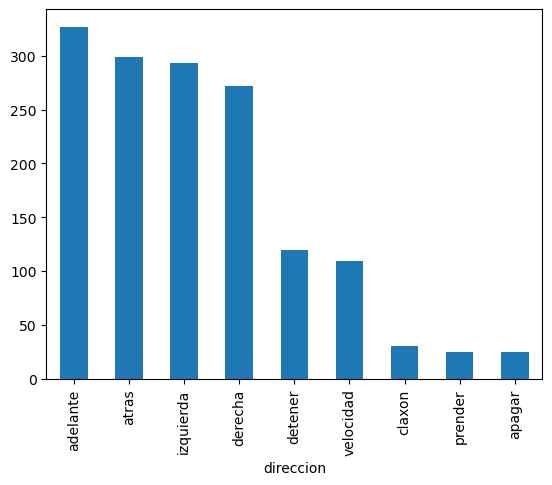

In [49]:
df['direccion'].value_counts().plot(kind='bar')

<Axes: xlabel='velocidad'>

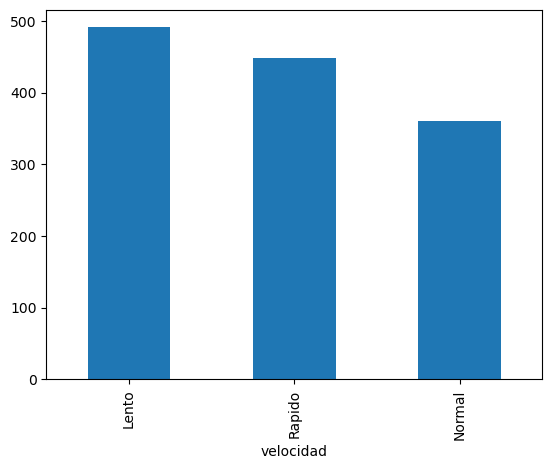

In [50]:
df['velocidad'].value_counts().plot(kind='bar')

<Axes: xlabel='estado_silla'>

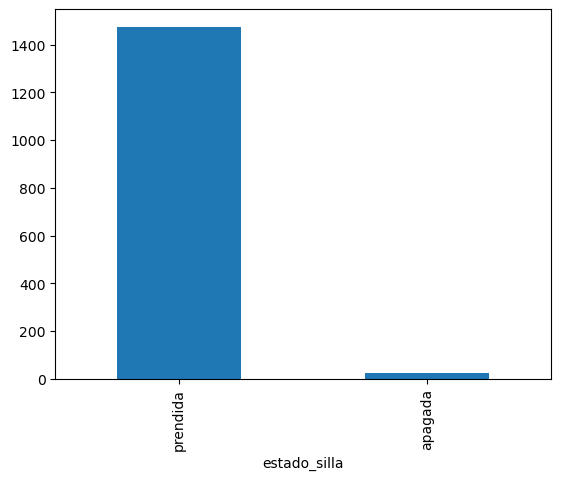

In [51]:
df['estado_silla'].value_counts().plot(kind='bar')

Vemos que las en la variable de salida de velocidad, se tiene una distribuciones de clases uniforme, mientras que en la de dirección y de estado hay un desbalance.
En el caso de la variable dirección las clases dominantes son las de las direcciones principales (izquierda, derecha, adelante y atrás) y en el caso de estado, la predominantes es la clase prendida.
Esto puede comprometer el entrenamiento de los modelos.


Relación entre palabras y acciones

In [63]:
df[df['direccion'] == 'derecha']['frase'].head(30)


1         da vuelta hacia la derecha mas rapido
20                ve para la derecha mas rapido
24              muevete hacia la derecha normal
25                gira pa' la derecha con calma
28                   voltea a la derecha normal
31               tuerce al lado derecho apurate
37              da vuelta para la derecha lento
41                           ve al lado derecho
42        dobla hacia la derecha mete velocidad
44     dobla hacia la derecha con mas velocidad
49                    da vuelta para la derecha
59            ve a la derecha con mas velocidad
67               tuerce para la derecha tranqui
71      dobla pa' la derecha a velocidad normal
76               dobla a la derecha con cuidado
79                            ve pa' la derecha
80                 dobla a la derecha despacito
83                  gira a la derecha despacito
97                     pa' la derecha con calma
99                   da vuelta hacia la derecha
110              al lado derecho mete ve

Se tiene una relación al 100% de las frases con las acciones, esto se debe a que el dataset fue generado de manera sintética usando ChatGPT.

Combinaciones de salida

In [62]:
df.groupby(['estado_silla','direccion', 'velocidad']).size()

estado_silla  direccion  velocidad
prendida      adelante   Lento        117
                         Normal        97
                         Rapido       113
              atras      Lento        109
                         Normal        96
                         Rapido        94
              derecha    Lento         94
                         Normal        76
                         Rapido       102
              izquierda  Lento        125
                         Normal        72
                         Rapido        96
              velocidad  Lento         46
                         Normal        20
                         Rapido        43
dtype: int64